# 2. Combo Volume Anomaly Detection

This notebook demonstrates how a single **FCVAE (Frequency-enhanced Conditional Variational Autoencoder)** architecture detects anomalies in transaction *volume* across 4 independent network/transaction-type combinations.

**Key insight:** The same model architecture handles 4 different frequency patterns (24h, 12h, 8h cycles) and catches both **spikes** (sudden increases) and **dips** (sudden drops) in transaction volume.

| Combo | Network | Txn Type | Base Rate | Period | Peak Hour |
|-------|---------|----------|-----------|--------|-----------|
| Accel_CMP | Accel | CMP | ~1765/hr | 24h | ~6 |
| Accel_nopin | Accel | no-pin | ~1370/hr | 12h | ~2, ~14 |
| Star_CMP | Star | CMP | ~2000/hr | 24h | ~18 |
| Star_nopin | Star | no-pin | ~1252/hr | 8h | ~2, ~8, ~14, ~20 |

See `1_combo_data_exploration.ipynb` for the EDA that motivates this analysis.

In [1]:
import sys
import warnings
import logging
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch

%matplotlib inline
import matplotlib.pyplot as plt

# Suppress PyTorch FFT resize warnings
warnings.filterwarnings("ignore", message=".*The default value of 'split'.*")
warnings.filterwarnings("ignore", message=".*Resize.*")

# Project root
if Path.cwd().name == "code":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Suppress verbose logging from src modules
for mod in ["src.preprocess", "src.model", "src.scorer", "src.train"]:
    logging.getLogger(mod).setLevel(logging.WARNING)

# Pickle compatibility for old module paths
import src.model
import src.scorer
sys.modules["app.fcvae_model"] = src.model
sys.modules["app.fcvae_scorer"] = src.scorer
sys.modules["app.attention"] = src.model
sys.modules["fcvae_model"] = src.model
sys.modules["fcvae_scorer"] = src.scorer
sys.modules["attention"] = src.model

from src.model import FCVAE, FCVAEConfig
from src.scorer import FCVAEScorer
from src.preprocess import load_combo_data, create_sliding_windows, create_splits, normalize, create_dataloaders, COMBO_KEYS
from src.utils import auto_device

device = auto_device()
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")

Project root: /Users/jonpaino/Documents/Striim/fcvae-anomaly-detection
Device: mps


## Load the 4 Combo Time Series

Each combo is an independent hourly count series of transaction volume for a (network_type, transaction_type) pair.

In [2]:
data_path = PROJECT_ROOT / "data" / "synthetic_transactions.csv"
combo_data = load_combo_data(data_path)

for combo, df in combo_data.items():
    key = f"{combo[0]}_{combo[1].replace('-', '')}"
    total = df["count"].sum()
    mean_h = df["count"].mean()
    anom = df["is_anomaly"].sum()
    print(f"{key:15s}  {len(df)} hours  {total:>10,} txns  {mean_h:>7.1f} mean/hr  {anom:>3} anomaly hours")

Accel_CMP        1440 hours   2,439,200 txns   1693.9 mean/hr   41 anomaly hours
Accel_nopin      1440 hours   1,870,812 txns   1299.2 mean/hr   41 anomaly hours
Star_CMP         1440 hours   2,798,320 txns   1943.3 mean/hr   41 anomaly hours
Star_nopin       1440 hours   1,744,527 txns   1211.5 mean/hr   41 anomaly hours


## Periodicity: 4 Different Frequency Patterns

Each combo has a distinct intraday cycle. The FCVAE's **Global Frequency Module (GFM)** captures these via FFT (Fast Fourier Transform) of the full window, while the **Local Frequency Module (LFM)** uses FFT of sub-windows + self-attention for local trends.

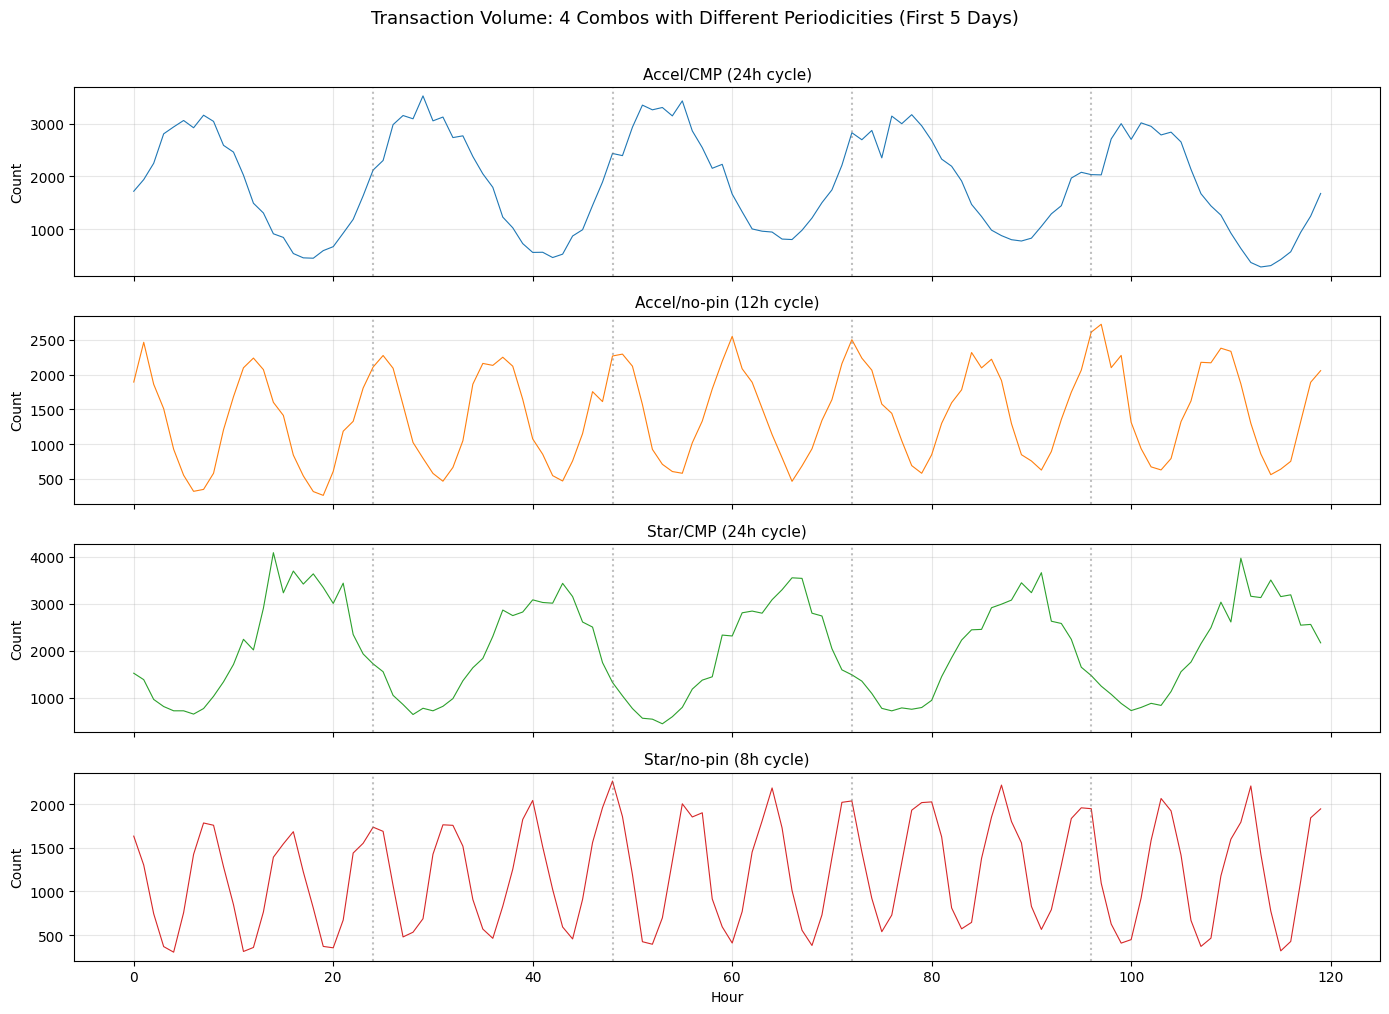

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), dpi=100, sharex=True)
combo_labels = {
    ("Accel", "CMP"): "Accel/CMP (24h cycle)",
    ("Accel", "no-pin"): "Accel/no-pin (12h cycle)",
    ("Star", "CMP"): "Star/CMP (24h cycle)",
    ("Star", "no-pin"): "Star/no-pin (8h cycle)",
}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Plot first 5 days of training data (days 0-4)
for i, combo in enumerate(COMBO_KEYS):
    df = combo_data[combo]
    hours = 5 * 24  # 5 days
    ax = axes[i]
    ax.plot(range(hours), df["count"].values[:hours], color=colors[i], linewidth=0.8)
    ax.set_ylabel("Count")
    ax.set_title(combo_labels[combo], fontsize=11)
    ax.grid(True, alpha=0.3)
    # Add day separators
    for d in range(1, 5):
        ax.axvline(d * 24, color="gray", linestyle=":", alpha=0.5)

axes[-1].set_xlabel("Hour")
fig.suptitle("Transaction Volume: 4 Combos with Different Periodicities (First 5 Days)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## FCVAE Architecture & Training Demo

The **FCVAE (Frequency-enhanced Conditional VAE)** adapts the standard VAE by conditioning on frequency-domain features. Here is the model configuration and a short training demo on one combo.

**Architecture summary:**
- **Encoder**: input window (24h) + frequency condition &rarr; hidden layers &rarr; latent mean &mu; and variance &sigma;&sup2;
- **Decoder**: latent sample z + frequency condition &rarr; hidden layers &rarr; output distribution (&mu;_x, &sigma;&sup2;_x)
- **GFM (Global Frequency Module)**: FFT of full window (excluding last point) &rarr; embedding
- **LFM (Local Frequency Module)**: FFT of 8-hour sub-windows + self-attention &rarr; embedding
- **Last-point masking**: position [-1] is zeroed in the frequency condition, making it a genuine prediction
- **Loss**: ELBO = reconstruction NLL + KLD (with KL warmup annealing)
- **Scoring**: per-point NLL where lower (more negative) = more anomalous

In [4]:
from src.train import AugmentConfig, compute_kl_weight, train_epoch, validate_epoch

# Show the model config
config = FCVAEConfig()
print("FCVAEConfig defaults:")
print(f"  window:           {config.window} (hourly counts per day)")
print(f"  latent_dim:       {config.latent_dim}")
print(f"  condition_emb_dim:{config.condition_emb_dim}")
print(f"  d_model:          {config.d_model} (attention dimension)")
print(f"  n_head:           {config.n_head}")
print(f"  kernel_size:      {config.kernel_size} (LFM sub-window)")
print(f"  stride:           {config.stride} (LFM stride)")
print(f"  hidden_dims:      {config.hidden_dims}")

# Build a fresh model to show param count
demo_model = FCVAE(config).to(device)
print(f"\nTotal parameters: {sum(p.numel() for p in demo_model.parameters()):,}")

# Prepare training data for one combo (Accel_CMP) to demo a few epochs
demo_combo = ("Accel", "CMP")
demo_df = combo_data[demo_combo]
demo_windows, demo_labels, demo_ts = create_sliding_windows(demo_df, window_size=24, stride=1)
demo_splits = create_splits(demo_windows, demo_labels, demo_ts, demo_df)
demo_norm, demo_scaler = normalize(demo_splits)
demo_loaders = create_dataloaders(demo_norm, batch_size=64)

print(f"\nTraining demo on Accel_CMP: {len(demo_loaders['train'].dataset)} train windows")

# Train for 3 epochs to show the training loop
optimizer = torch.optim.Adam(demo_model.parameters(), lr=5e-4)
augment_config = AugmentConfig()

print(f"\n{'Epoch':>5}  {'Train Loss':>12}  {'Val Loss':>12}  {'KL Weight':>10}")
print("-" * 45)
for epoch in range(3):
    kl_weight = compute_kl_weight(epoch, warmup_epochs=10)
    train_loss = train_epoch(demo_model, demo_loaders["train"], optimizer, kl_weight, device,
                             augment_config=augment_config, grad_clip=2.0)
    val_loss = validate_epoch(demo_model, demo_loaders["val"], device)
    print(f"{epoch+1:>5}  {train_loss:>12.6f}  {val_loss:>12.6f}  {kl_weight:>10.2f}")

print("\n(Demo only — for the rest of this notebook we use the fully-trained stored models.)")
del demo_model, optimizer  # free memory

FCVAEConfig defaults:
  window:           24 (hourly counts per day)
  latent_dim:       8
  condition_emb_dim:16
  d_model:          64 (attention dimension)
  n_head:           4
  kernel_size:      8 (LFM sub-window)
  stride:           4 (LFM stride)
  hidden_dims:      (64, 64)

Total parameters: 70,584

Training demo on Accel_CMP: 1008 train windows

Epoch    Train Loss      Val Loss   KL Weight
---------------------------------------------
    1      0.505326      0.883896        0.10
    2      0.342233      0.699316        0.20
    3      0.209588      0.560663        0.30

(Demo only — for the rest of this notebook we use the fully-trained stored models.)


## Load Pre-trained Combo Models

Each combo has its own FCVAE model, scaler, and scorer with an oracle threshold calibrated on validation data.

**Oracle thresholds** (NLL — Negative Log-Likelihood — where lower = more anomalous):
- Accel_CMP: -2.4211
- Accel_nopin: -2.5306
- Star_CMP: -1.7560
- Star_nopin: -1.8976

In [5]:
models = {}
scorers = {}
scalers = {}

ORACLE_THRESHOLDS = {
    ("Accel", "CMP"): -2.4211,
    ("Accel", "no-pin"): -2.5306,
    ("Star", "CMP"): -1.7560,
    ("Star", "no-pin"): -1.8976,
}

combo_dirs = {
    ("Accel", "CMP"): "Accel_CMP",
    ("Accel", "no-pin"): "Accel_nopin",
    ("Star", "CMP"): "Star_CMP",
    ("Star", "no-pin"): "Star_nopin",
}

for combo in COMBO_KEYS:
    model_dir = PROJECT_ROOT / "models" / "fcvae" / combo_dirs[combo]
    
    # Load model
    checkpoint = torch.load(model_dir / "model.pt", map_location=device, weights_only=False)
    config = checkpoint.get("config") or checkpoint.get("model_config") or FCVAEConfig()
    model = FCVAE(config).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    models[combo] = model
    
    # Load scorer and override with oracle threshold
    scorer = FCVAEScorer.load(model_dir / "scorer.pkl")
    scorers[combo] = scorer
    
    # Load scaler
    with open(model_dir / "scaler.pkl", "rb") as f:
        scalers[combo] = pickle.load(f)
    
    params = sum(p.numel() for p in model.parameters())
    key = combo_dirs[combo]
    print(f"{key:15s}  {params:,} params  threshold={ORACLE_THRESHOLDS[combo]:.4f}")

print(f"\nAll 4 models loaded on {device}.")

Accel_CMP        70,584 params  threshold=-2.4211
Accel_nopin      70,584 params  threshold=-2.5306
Star_CMP         70,584 params  threshold=-1.7560
Star_nopin       70,584 params  threshold=-1.8976

All 4 models loaded on mps.


## Prepare Test Data

Create sliding windows and normalize using the fitted scalers for each combo.

In [6]:
combo_loaders = {}
combo_splits_raw = {}  # unnormalized for plotting

for combo in COMBO_KEYS:
    df = combo_data[combo]
    windows, labels, timestamps = create_sliding_windows(df, window_size=24, stride=1)
    splits = create_splits(windows, labels, timestamps, df)
    combo_splits_raw[combo] = splits
    
    # Normalize using saved scaler (not fitting a new one)
    scaler = scalers[combo]
    normalized_splits = {}
    for name, (w, l) in splits.items():
        if len(w) == 0:
            normalized_splits[name] = (w, l)
            continue
        flat = w.flatten().reshape(-1, 1)
        normed = scaler.transform(flat)
        normalized_splits[name] = (normed.reshape(w.shape), l)
    
    loaders = create_dataloaders(normalized_splits, batch_size=64, shuffle_train=False)
    combo_loaders[combo] = {"loaders": loaders, "normalized": normalized_splits}
    
    key = combo_dirs[combo]
    test_w, test_l = splits["test"]
    windows_with_anom = (test_l.sum(axis=1) > 0).sum()
    unique_anom_hours = int(df.loc[df["split"] == "test", "is_anomaly"].sum()) if "split" in df.columns else "?"
    print(f"{key:15s}  test: {len(test_w)} windows ({windows_with_anom} overlap an anomaly, {unique_anom_hours} unique anomaly hours)")

Accel_CMP        test: 217 windows (131 overlap an anomaly, 21 unique anomaly hours)
Accel_nopin      test: 217 windows (131 overlap an anomaly, 21 unique anomaly hours)
Star_CMP         test: 217 windows (133 overlap an anomaly, 21 unique anomaly hours)
Star_nopin       test: 217 windows (128 overlap an anomaly, 21 unique anomaly hours)


## Spike Detection: 3x Volume Surge

On **test day 52** (day_offset=1 in test), all combos receive a 3x multiplier spike at hours 15-17.
The FCVAE reconstruction stays near the learned normal pattern while the actual counts shoot up.
The **NLL (Negative Log-Likelihood)** plummets at the spike points, crossing below the threshold.

In [7]:
def plot_reconstruction_anomaly(
    combo, window_idx, title_suffix="", anomaly_type="spike",
):
    """Plot a single anomaly window: original vs reconstruction with NLL scores."""
    model = models[combo]
    scorer = scorers[combo]
    scaler = scalers[combo]
    threshold = ORACLE_THRESHOLDS[combo]
    
    # Get raw and normalized windows
    raw_windows, raw_labels = combo_splits_raw[combo]["test"]
    norm_windows = combo_loaders[combo]["normalized"]["test"][0]
    
    raw_w = raw_windows[window_idx]
    labels = raw_labels[window_idx]
    norm_w = norm_windows[window_idx]
    
    # Get reconstruction
    x = torch.FloatTensor(norm_w).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        mu_x, var_x = model.reconstruct(x)
        scores = model.score_single_pass(x, n_samples=16).squeeze().cpu().numpy()
    
    mu_np = mu_x.squeeze().cpu().numpy()
    std_np = np.sqrt(var_x.squeeze().cpu().numpy())
    
    # Inverse transform to original scale
    mu_orig = scaler.inverse_transform(mu_np.reshape(-1, 1)).flatten()
    std_orig = std_np * scaler.scale_[0]
    
    hours = np.arange(24)
    is_anom = labels.astype(bool)
    peak_nll = scores[is_anom].min() if is_anom.any() else scores.min()
    
    combo_key = combo_dirs[combo]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), dpi=100, gridspec_kw={"height_ratios": [2, 1]})
    
    # Top: reconstruction
    ax1.plot(hours[~is_anom], raw_w[~is_anom], "o", color="steelblue", markersize=6, label="Normal")
    ax1.plot(hours[is_anom], raw_w[is_anom], "o", color="red", markersize=8, label="Anomalous")
    ax1.plot(hours, mu_orig, "--", color="gray", linewidth=1.5, label="Reconstruction ($\\mu_x$)")
    ax1.fill_between(hours, mu_orig - 2 * std_orig, mu_orig + 2 * std_orig,
                     alpha=0.15, color="gray", label="$\\pm 2\\sigma_x$")
    # Last-point marker
    ax1.plot(23, raw_w[23], "o", color="orange", markersize=10, markeredgecolor="darkorange",
             markeredgewidth=2, zorder=5, label="Last point (scored)")
    ax1.axvline(23, color="orange", linestyle=":", alpha=0.5)
    ax1.set_ylabel("Transaction Count")
    ax1.set_title(f"{combo_key}: {anomaly_type.title()} Detection — Peak NLL = {peak_nll:.2f} {title_suffix}", fontsize=12)
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Bottom: NLL scores
    bar_colors = ["red" if a else "steelblue" for a in is_anom]
    ax2.bar(hours, scores, color=bar_colors, alpha=0.7)
    ax2.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
                label=f"Threshold = {threshold:.2f}")
    ax2.set_xlabel("Hour of Day")
    ax2.set_ylabel("NLL Score")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()
    return scores

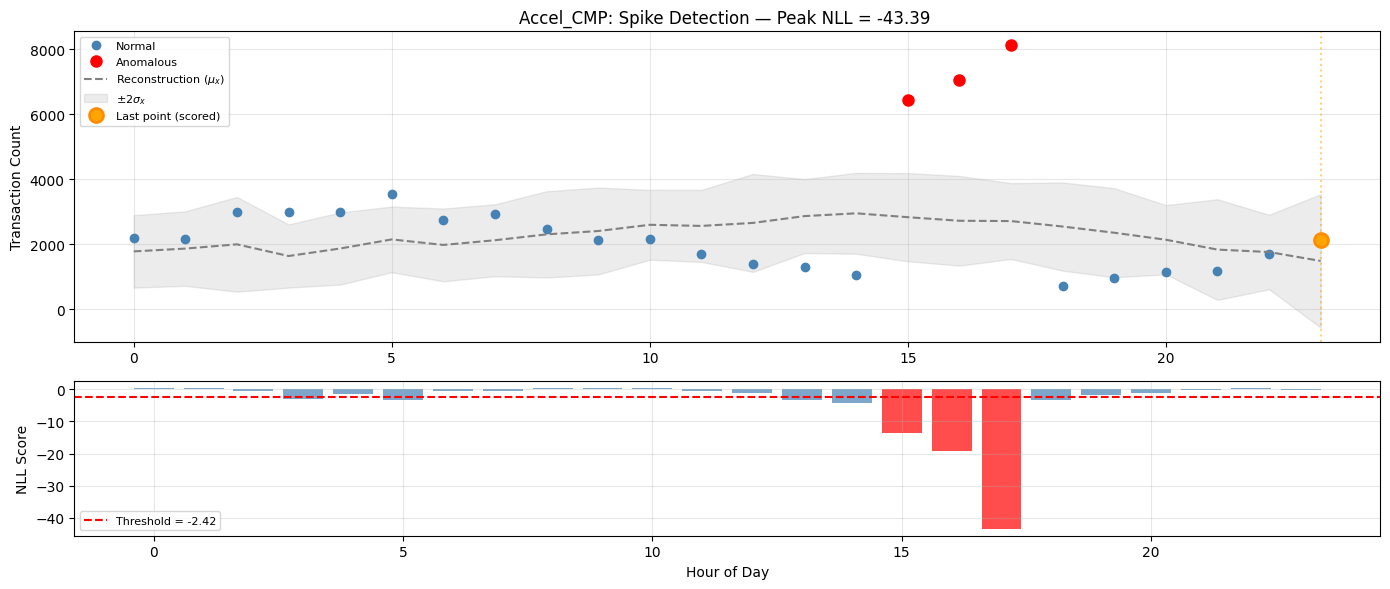

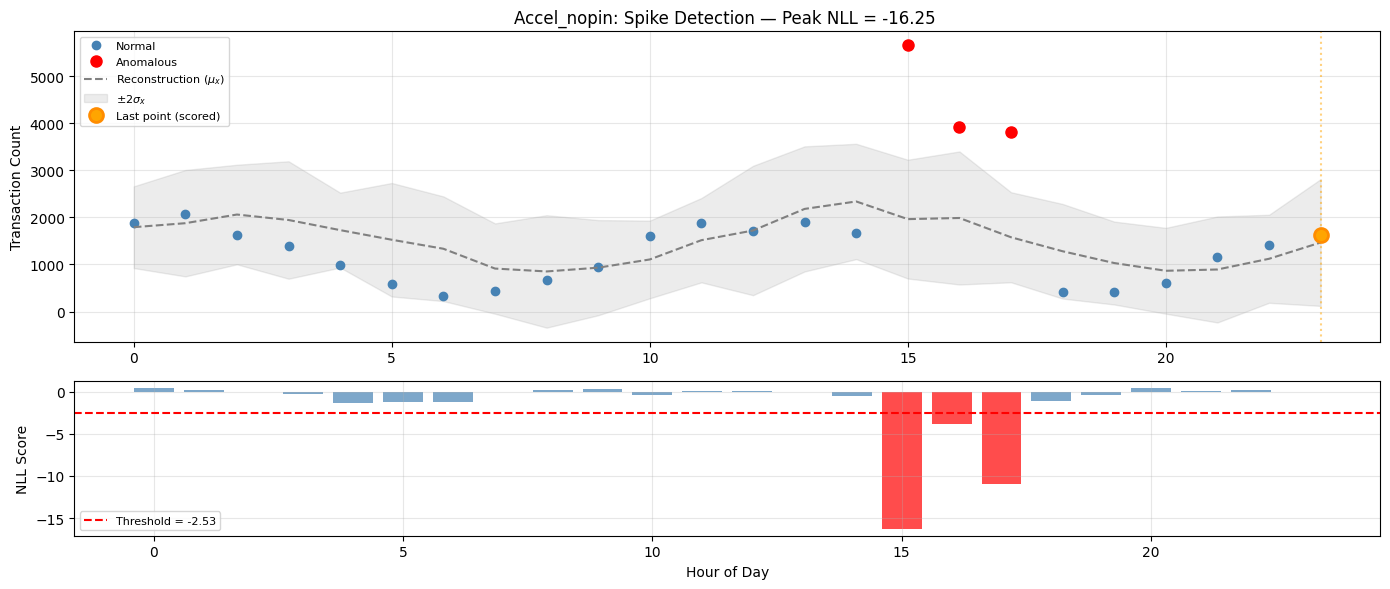

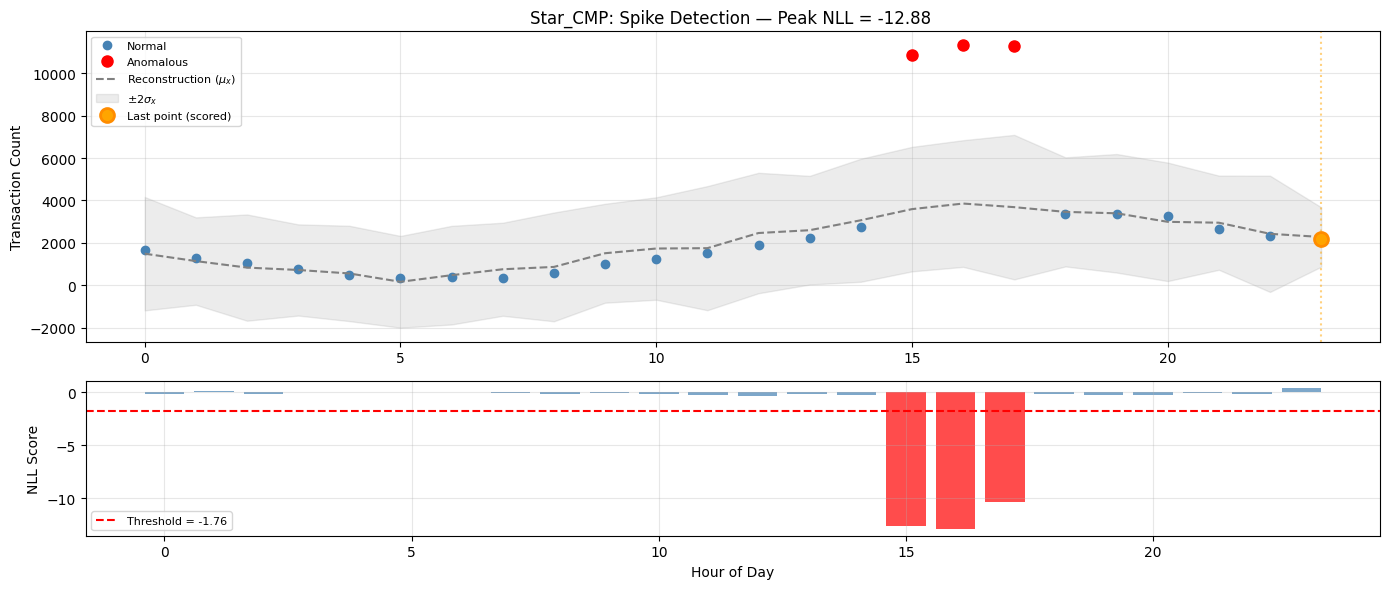

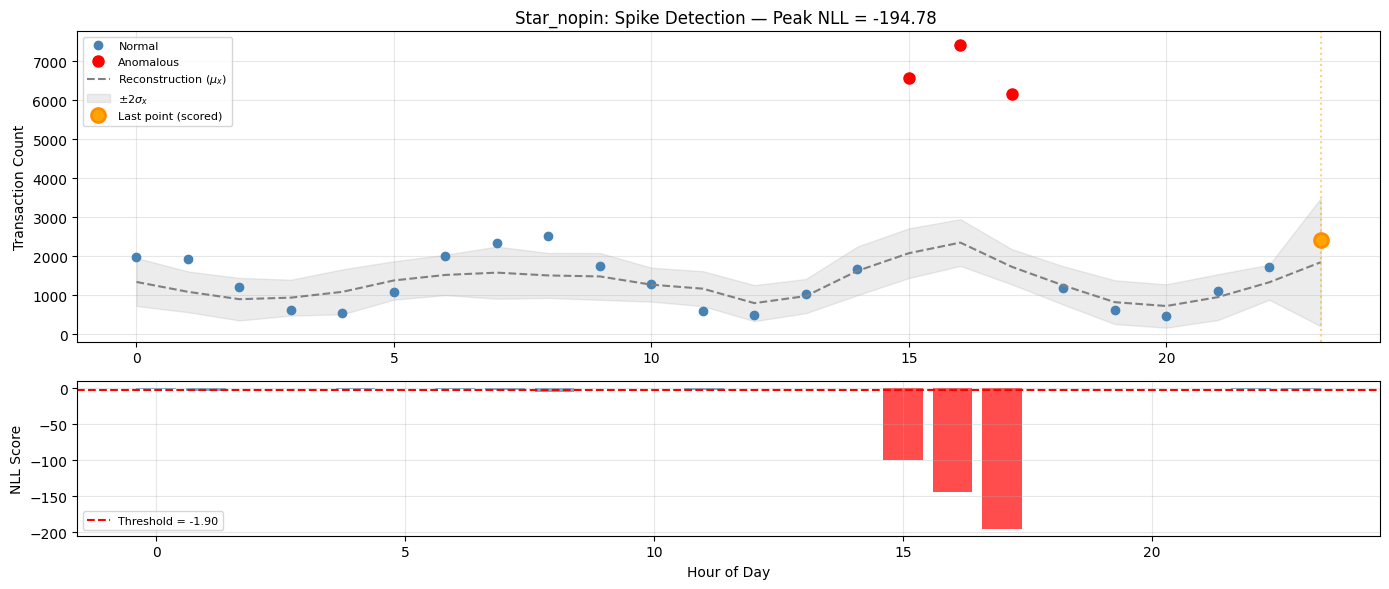

In [8]:
# Spike is on test day 52 (test offset 1) at hours 15-17 (3x multiplier).
# Window at day boundary: test hour offset 24 (= 1 * 24).
SPIKE_WINDOW_IDX = 1 * 24  # = 24

for combo in COMBO_KEYS:
    raw_windows, raw_labels = combo_splits_raw[combo]["test"]
    
    if SPIKE_WINDOW_IDX < len(raw_labels):
        _ = plot_reconstruction_anomaly(combo, SPIKE_WINDOW_IDX, anomaly_type="spike")
    else:
        key = combo_dirs[combo]
        print(f"{key}: Window index {SPIKE_WINDOW_IDX} out of range")

## Dip Detection: 90% Volume Drop

On **test day 56** (day_offset=5 in test), combos receive a 0.1x multiplier dip at their peak hours.
This is the key visual: the model expects ~2000 txns/hr but sees ~200. The NLL plummets because the observation falls far outside the learned distribution.

Dip hours vary by combo to hit each combo's peak:
- Accel_CMP & Accel_nopin: hour 11
- Star_CMP: hour 18
- Star_nopin: hour 8

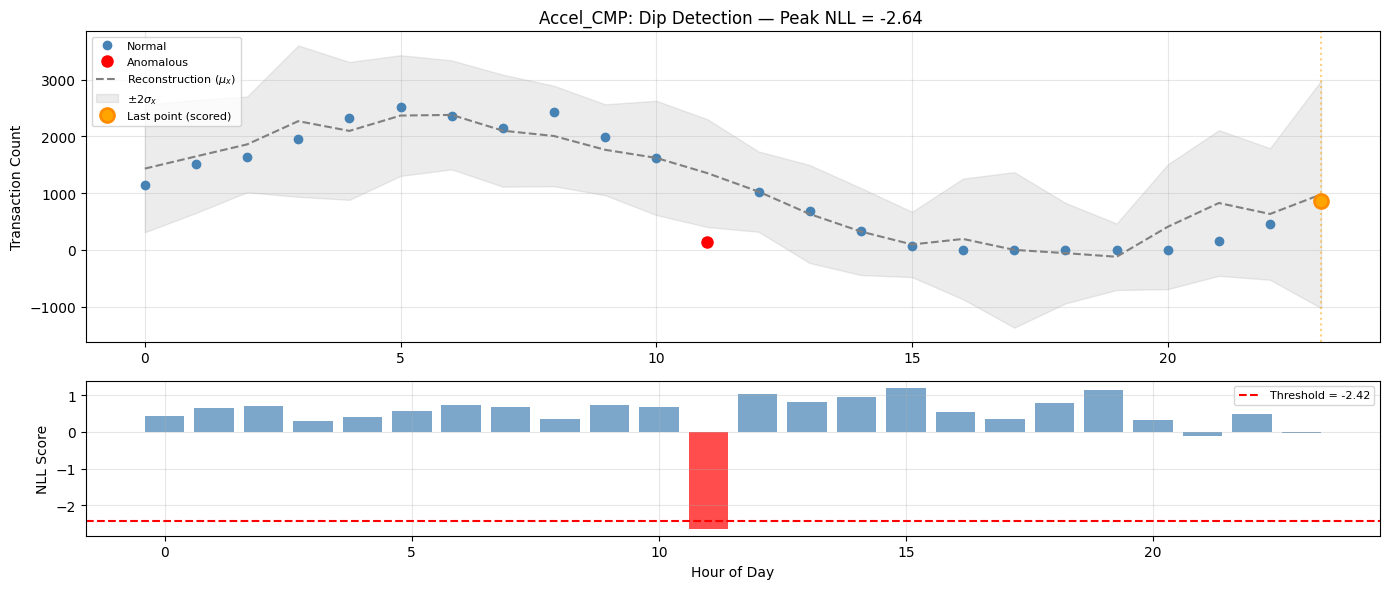

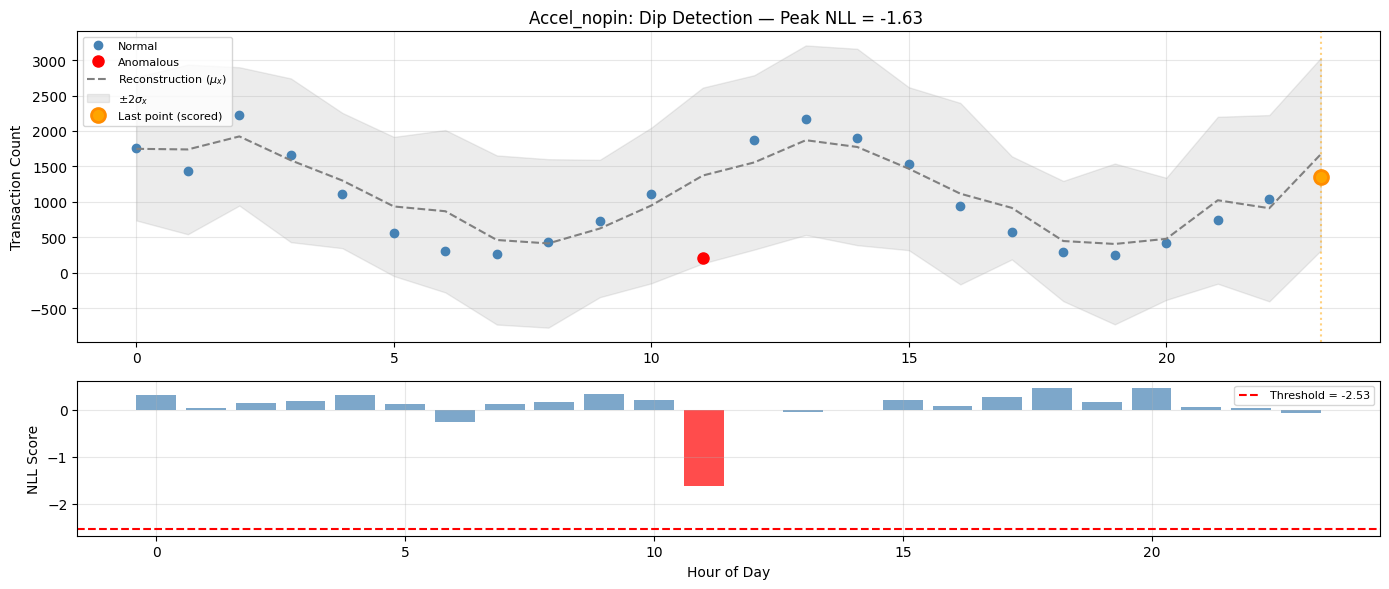

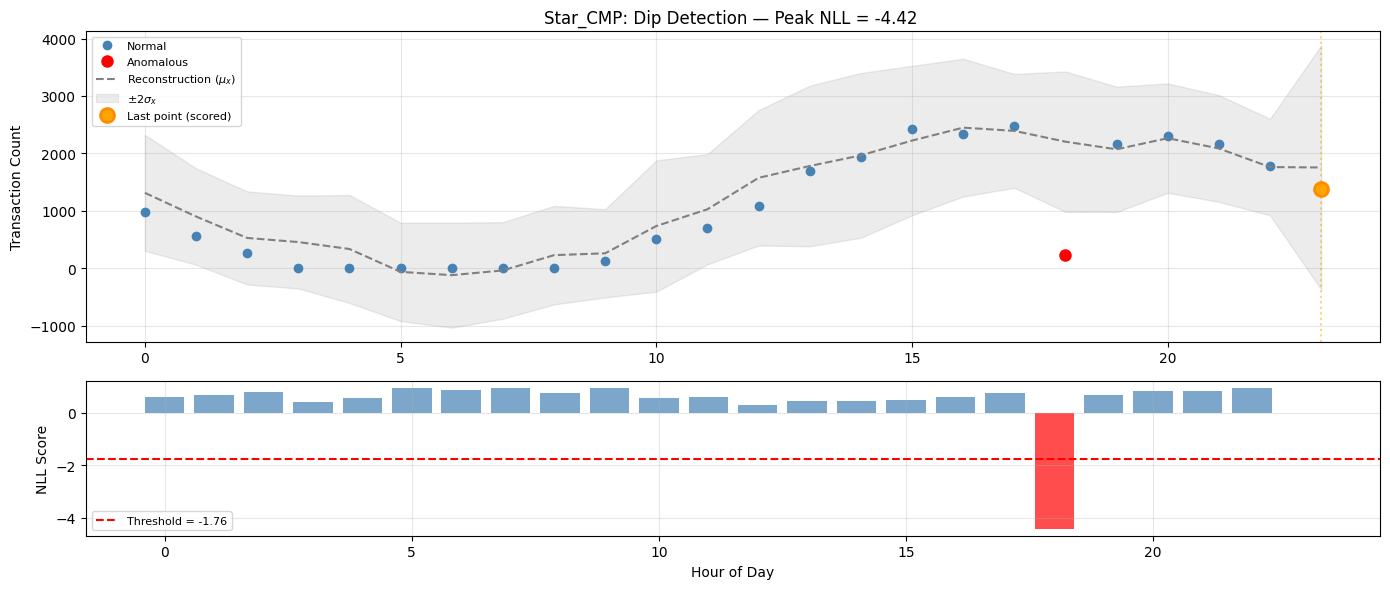

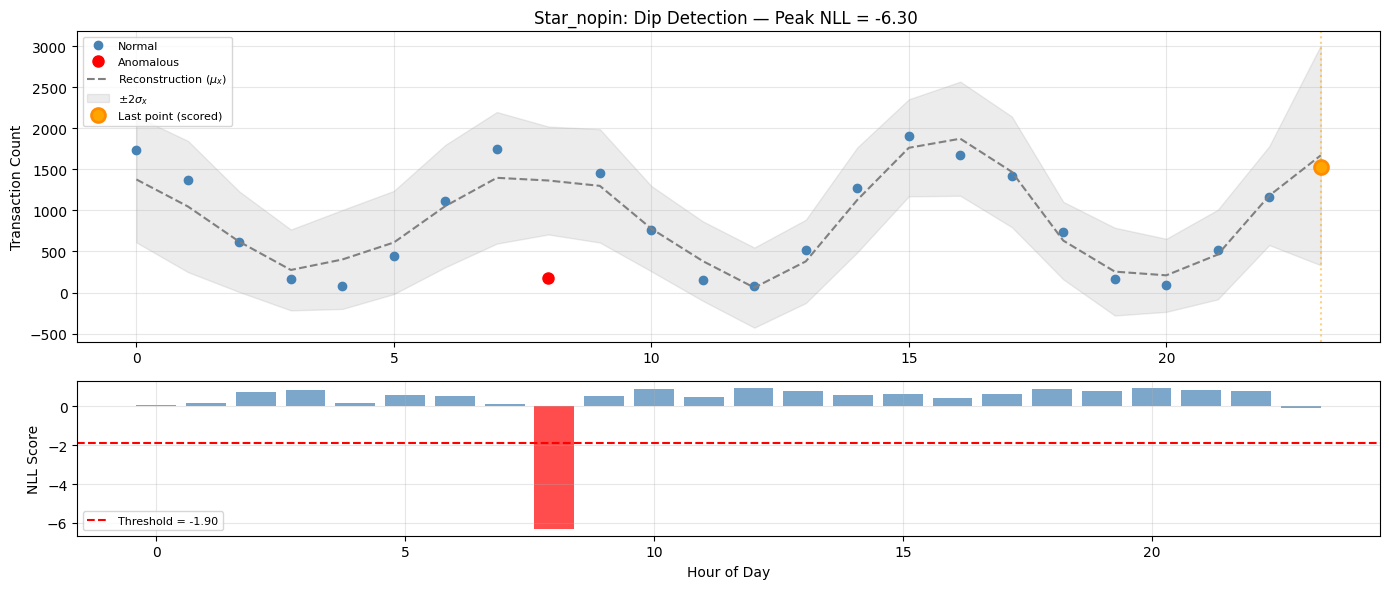

In [9]:
# Dip is on test day 56 (test offset 5), at combo-specific peak hours.
# With stride-1 sliding windows, we pick the window starting at day 56's boundary
# so that window position matches hour-of-day.
#
# Test period: 10 days (offsets 0-9). Day 56 = offset 5 → starts at test hour 120.
# Window index 120 gives a clean 24h view of day 56.
DIP_WINDOW_IDX = 5 * 24  # = 120

for combo in COMBO_KEYS:
    raw_windows, raw_labels = combo_splits_raw[combo]["test"]
    
    if DIP_WINDOW_IDX < len(raw_labels):
        _ = plot_reconstruction_anomaly(combo, DIP_WINDOW_IDX, anomaly_type="dip")
    else:
        key = combo_dirs[combo]
        print(f"{key}: Window index {DIP_WINDOW_IDX} out of range ({len(raw_labels)} windows)")

## Ramp Detection: Gradual Increase

On **validation day 47** (day_offset=4 in val), combos receive a gradual ramp from 1.5x to 2.5x at hours 8-11.
This is subtler than a sudden spike — the FCVAE must recognize that the progressive increase deviates from the learned pattern.

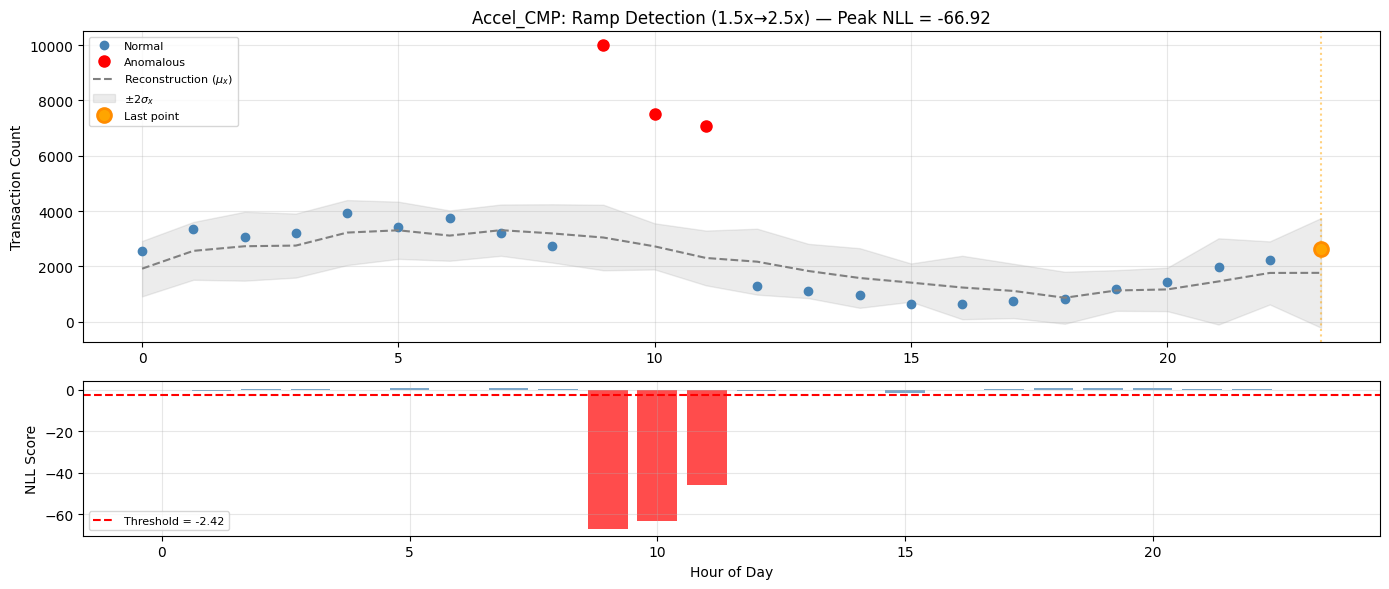

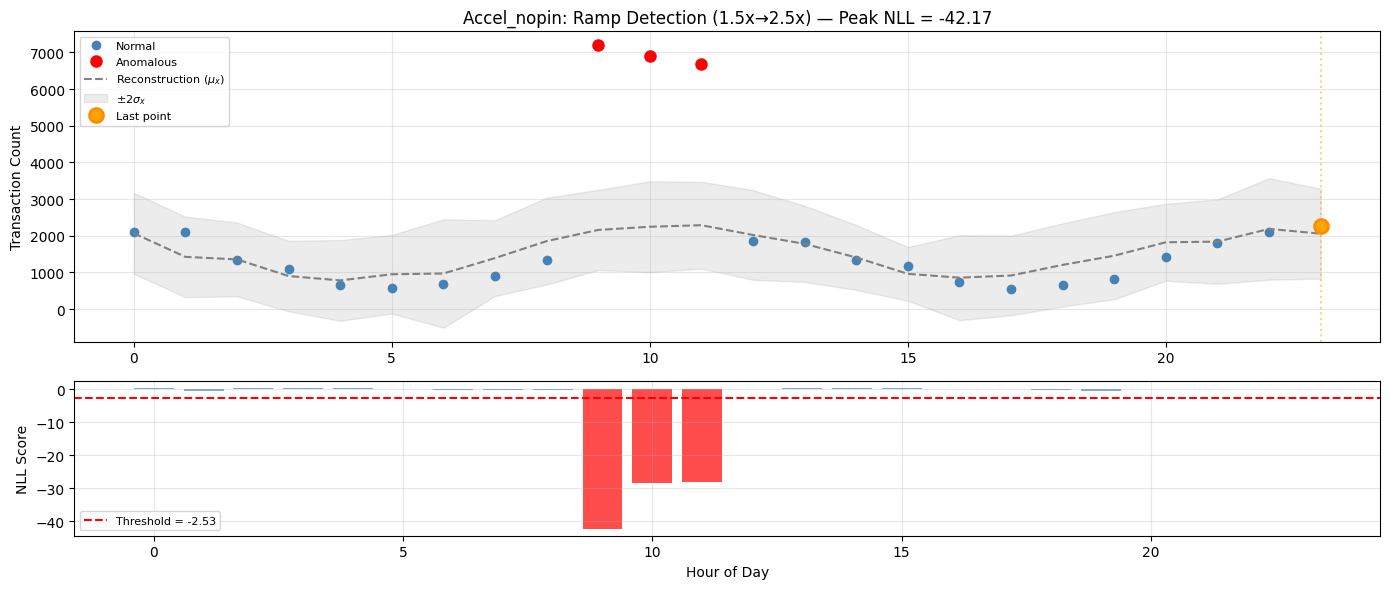

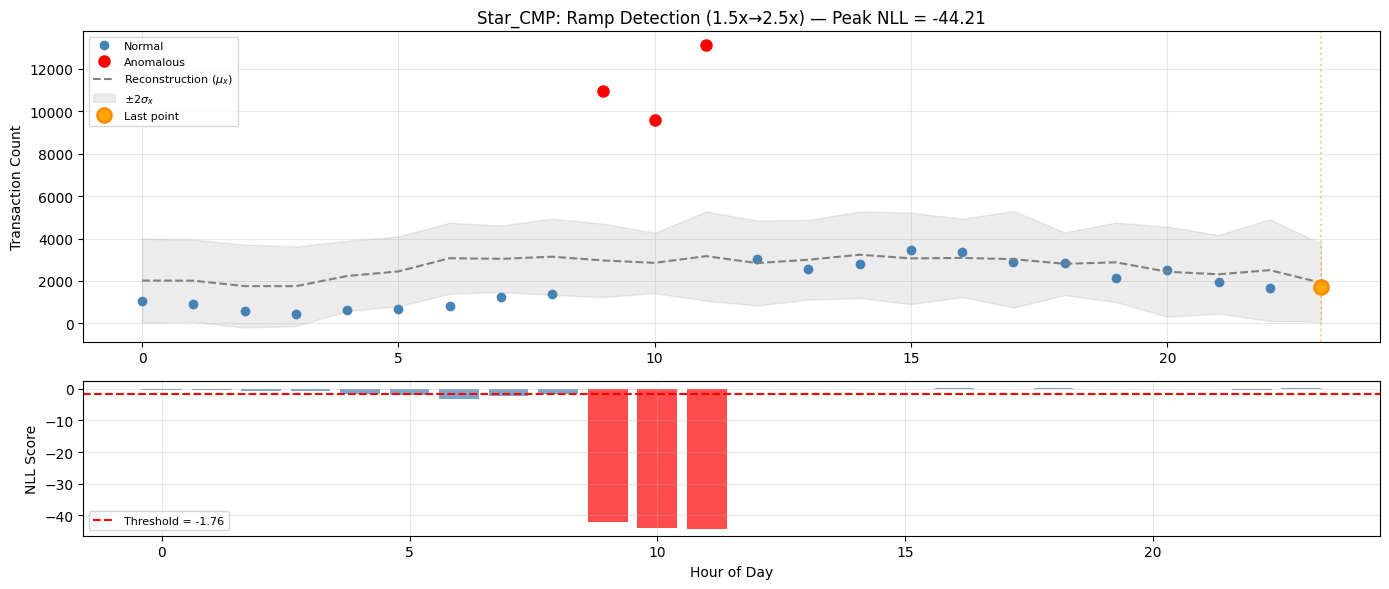

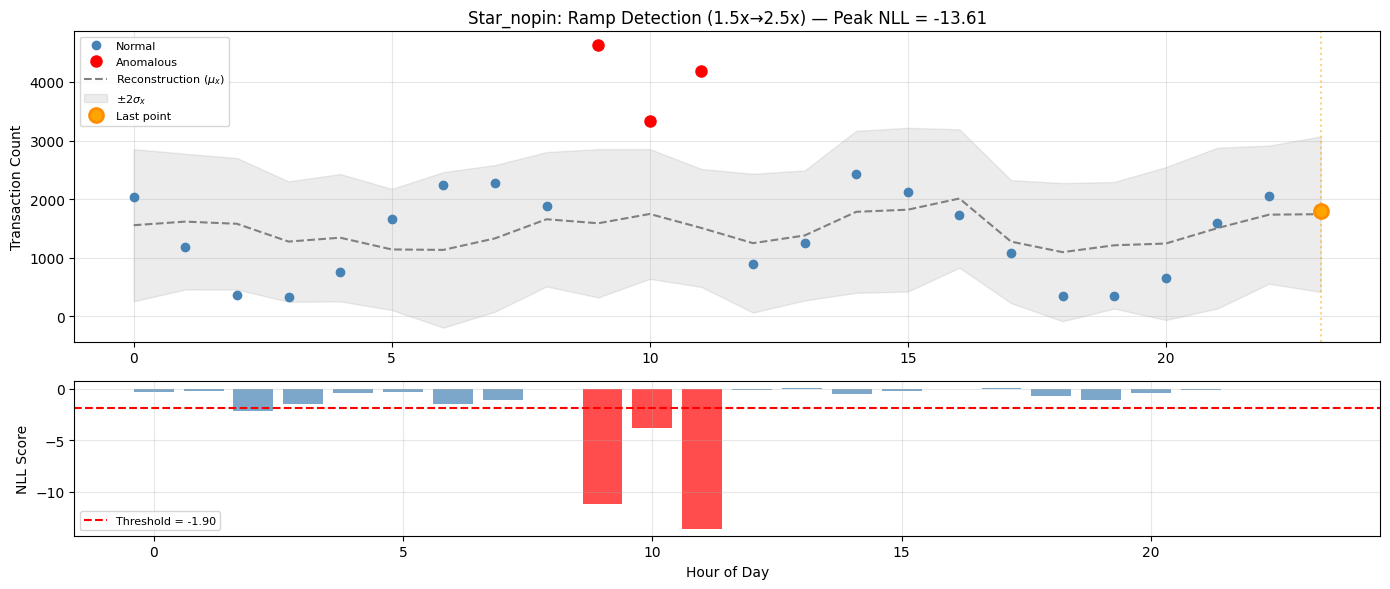

In [10]:
# Find ramp windows in validation set
for combo in COMBO_KEYS:
    val_windows, val_labels = combo_splits_raw[combo]["val"]
    norm_val = combo_loaders[combo]["normalized"]["val"][0]
    
    ramp_idx = None
    for i in range(len(val_labels)):
        anom_count = val_labels[i].sum()
        # Ramp has anomalies at hours 8-11 (4 hours)
        if 3 <= anom_count <= 5 and val_labels[i][8:12].sum() >= 3:
            ramp_idx = i
            break
    
    if ramp_idx is not None:
        # Plot using val data
        model = models[combo]
        scaler = scalers[combo]
        threshold = ORACLE_THRESHOLDS[combo]
        
        raw_w = val_windows[ramp_idx]
        labels = val_labels[ramp_idx]
        norm_w = norm_val[ramp_idx]
        
        x = torch.FloatTensor(norm_w).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            mu_x, var_x = model.reconstruct(x)
            scores = model.score_single_pass(x, n_samples=16).squeeze().cpu().numpy()
        
        mu_np = mu_x.squeeze().cpu().numpy()
        std_np = np.sqrt(var_x.squeeze().cpu().numpy())
        mu_orig = scaler.inverse_transform(mu_np.reshape(-1, 1)).flatten()
        std_orig = std_np * scaler.scale_[0]
        
        hours = np.arange(24)
        is_anom = labels.astype(bool)
        peak_nll = scores[is_anom].min() if is_anom.any() else scores.min()
        key = combo_dirs[combo]
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), dpi=100, gridspec_kw={"height_ratios": [2, 1]})
        
        ax1.plot(hours[~is_anom], raw_w[~is_anom], "o", color="steelblue", markersize=6, label="Normal")
        ax1.plot(hours[is_anom], raw_w[is_anom], "o", color="red", markersize=8, label="Anomalous")
        ax1.plot(hours, mu_orig, "--", color="gray", linewidth=1.5, label="Reconstruction ($\\mu_x$)")
        ax1.fill_between(hours, mu_orig - 2 * std_orig, mu_orig + 2 * std_orig,
                         alpha=0.15, color="gray", label="$\\pm 2\\sigma_x$")
        ax1.plot(23, raw_w[23], "o", color="orange", markersize=10, markeredgecolor="darkorange",
                 markeredgewidth=2, zorder=5, label="Last point")
        ax1.axvline(23, color="orange", linestyle=":", alpha=0.5)
        ax1.set_ylabel("Transaction Count")
        ax1.set_title(f"{key}: Ramp Detection (1.5x\u21922.5x) \u2014 Peak NLL = {peak_nll:.2f}", fontsize=12)
        ax1.legend(loc="upper left", fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        bar_colors = ["red" if a else "steelblue" for a in is_anom]
        ax2.bar(hours, scores, color=bar_colors, alpha=0.7)
        ax2.axhline(threshold, color="red", linestyle="--", linewidth=1.5,
                    label=f"Threshold = {threshold:.2f}")
        ax2.set_xlabel("Hour of Day")
        ax2.set_ylabel("NLL Score")
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        fig.tight_layout()
        plt.show()
    else:
        print(f"{combo_dirs[combo]}: No ramp window found in validation set")

## F1 Report per Combo (Point-Adjusted)

Evaluate on the **phase2 test dataset** (`synthetic_transactions_phase2.csv`) using **last-point scoring** with **oracle thresholds** and **point-adjusted F1** — the standard metric from the DONUT/FCVAE paper. If any point within a contiguous anomaly segment is detected, the entire segment counts as TP.

Phase2 is a dedicated 10-day test set with 3 anomaly events per combo (spike, dip, ramp).

In [11]:
# --- Point-adjusted F1 helpers ---
def find_contiguous_segments(labels):
    segments, in_seg, start = [], False, 0
    for i in range(len(labels)):
        if labels[i] and not in_seg: start, in_seg = i, True
        elif not labels[i] and in_seg: segments.append((start, i-1)); in_seg = False
    if in_seg: segments.append((start, len(labels)-1))
    return segments

def point_adjusted_f1(predictions, ground_truth):
    predictions = np.asarray(predictions, dtype=bool)
    ground_truth = np.asarray(ground_truth, dtype=bool)
    gt_segments = find_contiguous_segments(ground_truth)
    adjusted = predictions.copy()
    tp_segs, fn_segs = 0, 0
    for s, e in gt_segments:
        if np.any(predictions[s:e+1]):
            adjusted[s:e+1] = True; tp_segs += 1
        else:
            fn_segs += 1
    tp = int(np.sum(adjusted & ground_truth))
    fp = int(np.sum(adjusted & ~ground_truth))
    fn = int(np.sum(~adjusted & ground_truth))
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    return {"precision": prec, "recall": rec, "f1": f1,
            "tp_segments": tp_segs, "fn_segments": fn_segs, "total_segments": len(gt_segments)}

# --- Load phase2 test data ---
phase2_path = PROJECT_ROOT / "data" / "synthetic_transactions_phase2.csv"
phase2_combo_data = load_combo_data(phase2_path)

ORACLE_THRESHOLDS = {
    ("Accel", "CMP"): -2.4211,
    ("Accel", "no-pin"): -2.5306,
    ("Star", "CMP"): -1.7560,
    ("Star", "no-pin"): -1.8976,
}

print(f"{'Combo':<15} {'Threshold':>10} {'PA-Prec':>8} {'PA-Rec':>8} {'PA-F1':>8} {'Segments':>14}")
print("-" * 67)

for combo in COMBO_KEYS:
    model = models[combo]
    scaler = scalers[combo]
    threshold = ORACLE_THRESHOLDS[combo]

    # Prepare phase2 data: stride-1 sliding windows
    p2_df = phase2_combo_data[combo]
    p2_windows, p2_labels, p2_ts = create_sliding_windows(p2_df, window_size=24, stride=1)
    p2_norm = scaler.transform(p2_windows.flatten().reshape(-1,1)).reshape(p2_windows.shape)

    # Score each window, collect last-point scores
    from torch.utils.data import DataLoader, TensorDataset
    ds = TensorDataset(
        torch.FloatTensor(p2_norm).unsqueeze(1),
        torch.FloatTensor(p2_labels),
        torch.zeros_like(torch.FloatTensor(p2_labels))
    )
    loader = DataLoader(ds, batch_size=64, shuffle=False)

    scorer = scorers[combo]
    point_scores, _ = scorer.score_batch(model, loader, device)

    # Last-point evaluation
    lp_scores = point_scores[:, -1]
    lp_labels = p2_labels[:, -1].astype(bool)
    lp_preds = lp_scores < threshold

    pa = point_adjusted_f1(lp_preds, lp_labels)
    key = combo_dirs[combo]
    seg_str = f"{pa['tp_segments']}/{pa['total_segments']} detected"
    print(f"{key:<15} {threshold:>10.4f} {pa['precision']:>8.4f} {pa['recall']:>8.4f} {pa['f1']:>8.4f} {seg_str:>14}")

Combo            Threshold  PA-Prec   PA-Rec    PA-F1       Segments
-------------------------------------------------------------------
Accel_CMP          -2.4211   1.0000   0.8571   0.9231   2/3 detected
Accel_nopin        -2.5306   1.0000   1.0000   1.0000   3/3 detected
Star_CMP           -1.7560   1.0000   1.0000   1.0000   3/3 detected
Star_nopin         -1.8976   1.0000   1.0000   1.0000   3/3 detected


## Summary

The FCVAE architecture successfully handles:
1. **4 different frequency patterns** (24h, 12h, 8h cycles) using the same model architecture
2. **Bidirectional anomalies** — both spikes (volume surges) and dips (volume drops)
3. **Gradual anomalies** — ramps that progressively deviate from normal

The frequency conditioning modules (GFM + LFM) allow the model to learn each combo's unique periodicity without explicit feature engineering. The NLL-based scoring naturally captures both directions of deviation: any point that falls far from the learned distribution gets a low (more negative) score.

**Next:** See `3_penny_data_exploration.ipynb` for the penny transaction use case (carding attack detection), and `4_penny_model_design.ipynb` for a deep dive into the FCVAE architecture with interactive training.